# MLB Wins Prediction with AutoML

This notebook builds an **AutoML-style regression workflow** for MLB team win prediction.

It:
- loads `data.csv` and `predict.csv`
- applies the same schema safeguards as the updated production pipeline
- benchmarks multiple regression models using **time-aware cross-validation**
- selects the best model by **lowest MAE**
- fits the best model on all training data
- generates predictions for `predict.csv`

The notebook keeps the earlier improvements:
- permanent dropping of `SO`, `ER`, and `HRA`
- schema validation
- `TimeSeriesSplit` evaluation
- reproducible export of predictions and model summary


In [1]:
# Environment setup

import os
from pathlib import Path

LOCAL_DATA_DIR = Path(os.environ.get("LOCAL_DATA_DIR", Path.cwd())).resolve()
print(f"LOCAL_DATA_DIR set to: {LOCAL_DATA_DIR}")

LOCAL_DATA_DIR set to: /home/s_sofian/dsai/module_03/dsai-m3-5m-data-3.4-supervised-learning-advanced/kaggle


In [2]:
# Imports

import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Optional boosters
HAS_XGBOOST = True
HAS_LIGHTGBM = True

try:
    from xgboost import XGBRegressor
except Exception:
    HAS_XGBOOST = False

try:
    from lightgbm import LGBMRegressor
except Exception:
    HAS_LIGHTGBM = False

print("HAS_XGBOOST =", HAS_XGBOOST)
print("HAS_LIGHTGBM =", HAS_LIGHTGBM)

HAS_XGBOOST = False
HAS_LIGHTGBM = True


In [3]:
# Load datasets

DATA_DIR = LOCAL_DATA_DIR

data_df = pd.read_csv(DATA_DIR / "data.csv")
predict_df = pd.read_csv(DATA_DIR / "predict.csv")

print("Training shape:", data_df.shape)
print("Prediction shape:", predict_df.shape)

display(data_df.head())
display(predict_df.head())

Training shape: (1812, 51)
Prediction shape: (453, 45)


,yearID,teamID,G,R,AB,H,2B,3B,HR,BB,...,decade_1970,decade_1980,decade_1990,decade_2000,decade_2010,W,ID,year_label,decade_label,win_bins
0,1935,BOS,154,718,5288,1458,281,63,69,609,...,False,False,False,False,False,78,317,1935,1930s,3
1,1993,TEX,162,835,5510,1472,284,39,181,483,...,False,False,True,False,False,86,2162,1993,1990s,3
2,2016,SEA,162,768,5583,1446,251,17,223,506,...,False,False,False,False,True,86,1895,2016,2010s,3
3,1938,CHN,154,713,5333,1435,242,70,65,522,...,False,False,False,False,False,89,428,1938,1930s,3
4,1996,BOS,162,928,5756,1631,308,31,209,642,...,False,False,True,False,False,85,375,1996,1990s,3


,G,R,AB,H,2B,3B,HR,BB,SO,SB,...,decade_1930,decade_1940,decade_1950,decade_1960,decade_1970,decade_1980,decade_1990,decade_2000,decade_2010,ID
0,157,588,5221,1340,199,57,110,383,752.0,24,...,False,False,True,False,False,False,False,False,False,1756
1,161,707,5417,1353,215,40,167,597,840.0,47,...,False,False,False,True,False,False,False,False,False,1282
2,162,743,5494,1381,234,37,197,658,923.0,41,...,False,False,False,True,False,False,False,False,False,351
3,156,828,5451,1578,340,66,84,577,641.0,49,...,True,False,False,False,False,False,False,False,False,421
4,162,818,5595,1494,284,35,208,587,1052.0,71,...,False,False,False,False,False,False,False,True,False,57


In [4]:
# Configuration

TARGET = "W"

EXCLUDED_COLUMNS = {
    "W",            # target
    "ID",           # row identifier
    "win_bins",     # target-derived bucket; leakage risk
    "year_label",   # duplicate metadata
    "decade_label", # duplicate metadata
}

# Verified earlier as safe to drop for the tuned sparse linear model.
SAFE_DROP_COLUMNS = ["SO", "ER", "HRA"]

N_SPLITS = 5
RANDOM_STATE = 42

In [5]:
# Feature selection and schema validation

def build_feature_list(train_df: pd.DataFrame, pred_df: pd.DataFrame) -> list[str]:
    shared = [c for c in train_df.columns if c in pred_df.columns]
    features = [
        c for c in shared
        if c not in EXCLUDED_COLUMNS and c not in SAFE_DROP_COLUMNS
    ]
    return features

def validate_schema(df: pd.DataFrame, expected_columns: list[str], dataset_name: str = "dataset") -> pd.DataFrame:
    current = list(df.columns)
    extra = [c for c in current if c not in expected_columns]
    missing = [c for c in expected_columns if c not in current]

    if extra:
        print(f"{dataset_name}: dropping unexpected columns: {extra}")
        df = df.drop(columns=extra, errors="ignore")

    if missing:
        print(f"{dataset_name}: adding missing columns with 0: {missing}")
        for col in missing:
            df[col] = 0

    return df.reindex(columns=expected_columns, fill_value=0)

feature_cols = build_feature_list(data_df, predict_df)

X = data_df[feature_cols].copy()
y = data_df[TARGET].copy()
X_predict = predict_df[feature_cols].copy()

X = validate_schema(X, feature_cols, "train")
X_predict = validate_schema(X_predict, feature_cols, "predict")

print(f"Feature count: {len(feature_cols)}")
print("Dropped columns:", SAFE_DROP_COLUMNS)
print("X shape:", X.shape)
print("X_predict shape:", X_predict.shape)

Feature count: 41
Dropped columns: ['SO', 'ER', 'HRA']
X shape: (1812, 41)
X_predict shape: (453, 41)


In [6]:
# AutoML search space

def make_linear_pipeline(model):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model),
    ])

def make_tree_pipeline(model):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", model),
    ])

search_space = {
    "ElasticNet": {
        "builder": lambda params: make_linear_pipeline(
            ElasticNet(
                alpha=params["alpha"],
                l1_ratio=params["l1_ratio"],
                max_iter=10000,
                random_state=RANDOM_STATE,
            )
        ),
        "params": list(ParameterGrid({
            "alpha": [0.001, 0.01, 0.05, 0.1],
            "l1_ratio": [0.3, 0.5, 0.7, 0.9],
        })),
    },
    "Ridge": {
        "builder": lambda params: make_linear_pipeline(
            Ridge(alpha=params["alpha"], random_state=RANDOM_STATE)
        ),
        "params": list(ParameterGrid({
            "alpha": [0.01, 0.1, 1.0, 10.0, 50.0],
        })),
    },
    "RandomForest": {
        "builder": lambda params: make_tree_pipeline(
            RandomForestRegressor(
                n_estimators=params["n_estimators"],
                max_depth=params["max_depth"],
                min_samples_leaf=params["min_samples_leaf"],
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )
        ),
        "params": list(ParameterGrid({
            "n_estimators": [300, 600],
            "max_depth": [4, 6, 10, None],
            "min_samples_leaf": [1, 2, 4],
        })),
    },
    "ExtraTrees": {
        "builder": lambda params: make_tree_pipeline(
            ExtraTreesRegressor(
                n_estimators=params["n_estimators"],
                max_depth=params["max_depth"],
                min_samples_leaf=params["min_samples_leaf"],
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )
        ),
        "params": list(ParameterGrid({
            "n_estimators": [300, 600],
            "max_depth": [4, 6, 10, None],
            "min_samples_leaf": [1, 2, 4],
        })),
    },
    "GradientBoosting": {
        "builder": lambda params: make_tree_pipeline(
            GradientBoostingRegressor(
                n_estimators=params["n_estimators"],
                learning_rate=params["learning_rate"],
                max_depth=params["max_depth"],
                random_state=RANDOM_STATE,
            )
        ),
        "params": list(ParameterGrid({
            "n_estimators": [100, 300],
            "learning_rate": [0.03, 0.05, 0.1],
            "max_depth": [2, 3, 4],
        })),
    },
    "HistGradientBoosting": {
        "builder": lambda params: make_tree_pipeline(
            HistGradientBoostingRegressor(
                learning_rate=params["learning_rate"],
                max_depth=params["max_depth"],
                max_iter=params["max_iter"],
                min_samples_leaf=params["min_samples_leaf"],
                random_state=RANDOM_STATE,
            )
        ),
        "params": list(ParameterGrid({
            "learning_rate": [0.03, 0.05, 0.1],
            "max_depth": [3, 5, None],
            "max_iter": [200, 400],
            "min_samples_leaf": [10, 20],
        })),
    },
}

if HAS_XGBOOST:
    search_space["XGBoost"] = {
        "builder": lambda params: make_tree_pipeline(
            XGBRegressor(
                n_estimators=params["n_estimators"],
                learning_rate=params["learning_rate"],
                max_depth=params["max_depth"],
                subsample=params["subsample"],
                colsample_bytree=params["colsample_bytree"],
                reg_lambda=params["reg_lambda"],
                objective="reg:squarederror",
                random_state=RANDOM_STATE,
                n_jobs=1,
                verbosity=0,
            )
        ),
        "params": list(ParameterGrid({
            "n_estimators": [200, 400],
            "learning_rate": [0.03, 0.05, 0.1],
            "max_depth": [2, 3, 4],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0],
            "reg_lambda": [1.0, 5.0],
        })),
    }

if HAS_LIGHTGBM:
    search_space["LightGBM"] = {
        "builder": lambda params: make_tree_pipeline(
            LGBMRegressor(
                n_estimators=params["n_estimators"],
                learning_rate=params["learning_rate"],
                max_depth=params["max_depth"],
                num_leaves=params["num_leaves"],
                min_child_samples=params["min_child_samples"],
                random_state=RANDOM_STATE,
                verbosity=-1,
            )
        ),
        "params": list(ParameterGrid({
            "n_estimators": [200, 400],
            "learning_rate": [0.03, 0.05, 0.1],
            "max_depth": [-1, 3, 5],
            "num_leaves": [15, 31, 63],
            "min_child_samples": [5, 10, 20],
        })),
    }

for model_name, spec in search_space.items():
    print(f"{model_name}: {len(spec['params'])} parameter combinations")

ElasticNet: 16 parameter combinations
Ridge: 5 parameter combinations
RandomForest: 24 parameter combinations
ExtraTrees: 24 parameter combinations
GradientBoosting: 18 parameter combinations
HistGradientBoosting: 36 parameter combinations
LightGBM: 162 parameter combinations


In [7]:
# AutoML evaluation

def evaluate_candidate(model, X, y, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)

    maes = []
    rmses = []
    r2s = []

    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        fitted = clone(model)
        fitted.fit(X_train, y_train)
        preds = fitted.predict(X_test)

        maes.append(mean_absolute_error(y_test, preds))
        rmses.append(np.sqrt(mean_squared_error(y_test, preds)))
        r2s.append(r2_score(y_test, preds))

    return {
        "mae": float(np.mean(maes)),
        "rmse": float(np.mean(rmses)),
        "r2": float(np.mean(r2s)),
    }

results = []
best_model_name = None
best_params = None
best_pipeline = None
best_mae = float("inf")

for model_name, spec in search_space.items():
    print(f"\nSearching {model_name}...")
    local_best_mae = float("inf")
    local_best_params = None

    for i, params in enumerate(spec["params"], start=1):
        pipeline = spec["builder"](params)
        metrics = evaluate_candidate(pipeline, X, y, n_splits=N_SPLITS)

        row = {
            "model": model_name,
            "params": params,
            "mae": metrics["mae"],
            "rmse": metrics["rmse"],
            "r2": metrics["r2"],
        }
        results.append(row)

        if metrics["mae"] < local_best_mae:
            local_best_mae = metrics["mae"]
            local_best_params = params

        if metrics["mae"] < best_mae:
            best_mae = metrics["mae"]
            best_model_name = model_name
            best_params = params
            best_pipeline = pipeline

    print(f"Best {model_name} MAE: {local_best_mae:.5f} with params: {local_best_params}")

results_df = pd.DataFrame(results).sort_values(["mae", "rmse", "r2"], ascending=[True, True, False]).reset_index(drop=True)

print("\nTop 15 AutoML candidates:")
display(results_df.head(15))


Searching ElasticNet...
Best ElasticNet MAE: 2.80059 with params: {'alpha': 0.01, 'l1_ratio': 0.9}

Searching Ridge...
Best Ridge MAE: 2.80409 with params: {'alpha': 0.01}

Searching RandomForest...
Best RandomForest MAE: 3.62179 with params: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 300}

Searching ExtraTrees...
Best ExtraTrees MAE: 3.48266 with params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 300}

Searching GradientBoosting...
Best GradientBoosting MAE: 3.35101 with params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}

Searching HistGradientBoosting...
Best HistGradientBoosting MAE: 3.32491 with params: {'learning_rate': 0.03, 'max_depth': 3, 'max_iter': 400, 'min_samples_leaf': 10}

Searching LightGBM...
Best LightGBM MAE: 3.35082 with params: {'learning_rate': 0.05, 'max_depth': 3, 'min_child_samples': 10, 'n_estimators': 400, 'num_leaves': 15}

Top 15 AutoML candidates:


,model,params,mae,rmse,r2
0,ElasticNet,"{'alpha': 0.01, 'l1_ratio': 0.9}",2.800589,3.551107,0.926895
1,ElasticNet,"{'alpha': 0.001, 'l1_ratio': 0.9}",2.802729,3.556160,0.926686
2,ElasticNet,"{'alpha': 0.001, 'l1_ratio': 0.7}",2.803341,3.556548,0.926671
3,ElasticNet,"{'alpha': 0.001, 'l1_ratio': 0.5}",2.803987,3.557004,0.926653
4,Ridge,{'alpha': 0.01},2.804088,3.558624,0.926582
5,Ridge,{'alpha': 0.1},2.804361,3.558243,0.926598
6,ElasticNet,"{'alpha': 0.001, 'l1_ratio': 0.3}",2.804688,3.557532,0.926631
7,Ridge,{'alpha': 1.0},2.807885,3.558402,0.926595
8,ElasticNet,"{'alpha': 0.01, 'l1_ratio': 0.7}",2.809840,3.559555,0.926542
9,ElasticNet,"{'alpha': 0.01, 'l1_ratio': 0.5}",2.818793,3.568611,0.926162


In [12]:
# Best model summary and refit

print("Best model selected by AutoML search")
print("Model:", best_model_name)
print("Params:", best_params)
print(f"Best CV MAE : {best_mae:.5f}")

best_pipeline.fit(X, y)

# Store training predictions for optional diagnostics
train_preds = best_pipeline.predict(X)

# Save leaderboards
leaderboard_path = DATA_DIR / "automl_leaderboard.csv"
results_df.to_csv(leaderboard_path, index=False)

print(f"Saved leaderboard to: {leaderboard_path}")

Best model selected by AutoML search
Model: ElasticNet
Params: {'alpha': 0.01, 'l1_ratio': 0.9}
Best CV MAE : 2.80059
Saved leaderboard to: /home/s_sofian/dsai/module_03/dsai-m3-5m-data-3.4-supervised-learning-advanced/kaggle/automl_leaderboard.csv


In [13]:
# Feature diagnostics

model_step = best_pipeline.named_steps["model"]

feature_importance_df = None

if hasattr(model_step, "coef_"):
    feature_importance_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": np.abs(model_step.coef_),
    }).sort_values("Importance", ascending=False).reset_index(drop=True)
    print("Using absolute coefficients as feature importance.")
elif hasattr(model_step, "feature_importances_"):
    feature_importance_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": model_step.feature_importances_,
    }).sort_values("Importance", ascending=False).reset_index(drop=True)
    print("Using model feature_importances_.")
else:
    print("This model does not expose direct feature importance.")

if feature_importance_df is not None:
    display(feature_importance_df.head(15))

Using absolute coefficients as feature importance.


,Feature,Importance
0,R,8.641735
1,RA,5.906234
2,AB,5.228636
3,IPouts,4.745582
4,SV,4.263540
5,CG,3.605269
6,H,2.814251
7,E,0.840357
8,SHO,0.804336
9,era_1,0.708151


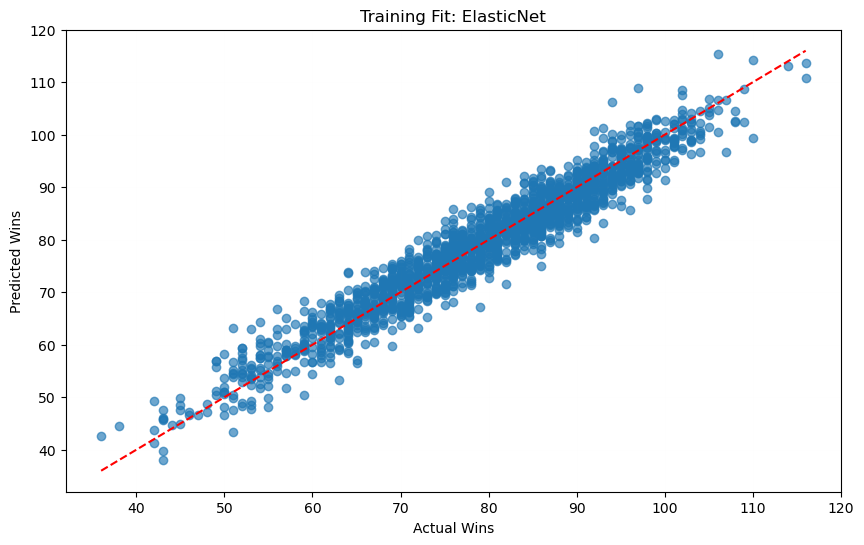

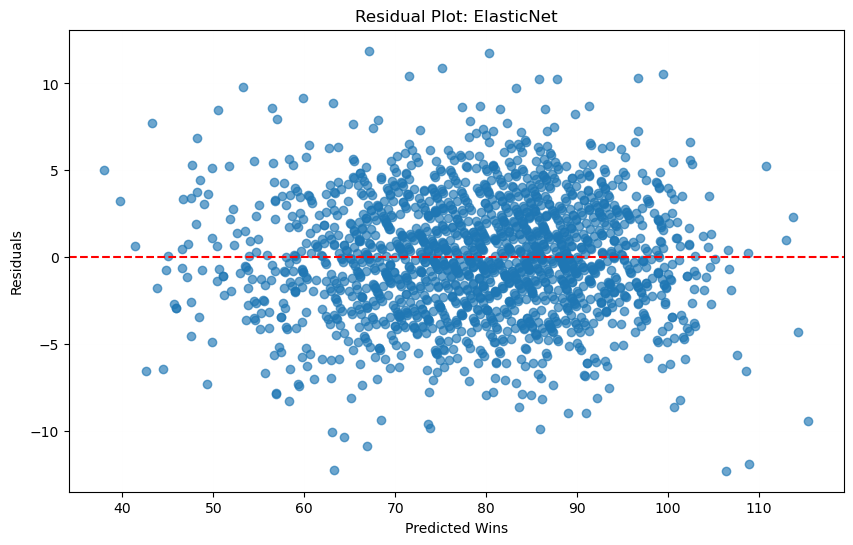

In [37]:
# Diagnostic plots

plt.figure(figsize=(10, 6))
plt.scatter(y, train_preds, alpha=0.65)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.xlabel("Actual Wins")
plt.ylabel("Predicted Wins")
plt.title(f"Training Fit: {best_model_name}")
plt.grid(True, alpha=0.01)
plt.show()

plt.figure(figsize=(10, 6))
residuals = y - train_preds
plt.scatter(train_preds, residuals, alpha=0.65)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Predicted Wins")
plt.ylabel("Residuals")
plt.title(f"Residual Plot: {best_model_name}")
plt.grid(True, alpha=0.01)
plt.show()

In [38]:
# Predict on scoring data and export artifacts

predict_preds = best_pipeline.predict(X_predict)

submission_df = pd.DataFrame({
    "ID": predict_df["ID"],
    "W": np.round(predict_preds).astype(int)
})

submission_path = DATA_DIR / "submission_predict_automl3.csv"
submission_df.to_csv(submission_path, index=False)

summary_payload = {
    "target": TARGET,
    "feature_columns": feature_cols,
    "safe_drop_columns": SAFE_DROP_COLUMNS,
    "excluded_columns": sorted(EXCLUDED_COLUMNS),
    "cv_type": "TimeSeriesSplit",
    "n_splits": N_SPLITS,
    "best_model": best_model_name,
    "best_params": best_params,
    "best_cv_mae": float(best_mae),
}

summary_path = DATA_DIR / "automl_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary_payload, f, indent=2)

print(f"Saved predictions to: {submission_path}")
print(f"Saved AutoML summary to: {summary_path}")

display(submission_df.head())

Saved predictions to: /home/s_sofian/dsai/module_03/dsai-m3-5m-data-3.4-supervised-learning-advanced/kaggle/submission_predict_automl3.csv
Saved AutoML summary to: /home/s_sofian/dsai/module_03/dsai-m3-5m-data-3.4-supervised-learning-advanced/kaggle/automl_summary.json


,ID,W
0,1756,70
1,1282,74
2,351,84
3,421,87
4,57,94
